## Упражнение 6.1

In [1]:
import timeit

import numpy as np
import matplotlib.pyplot as plt
import scipy.fftpack
from scipy.stats import linregress

from thinkdsp import UncorrelatedGaussianNoise, decorate

PI2 = np.pi * 2

In [2]:
def analyze1(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.linalg.solve(M, ys)
    return amps


def analyze2(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = M.dot(ys) / 2
    return amps


def dct_iv(ys, fs=None, ts=None):
    N = len(ys)
    ts = (0.5 + np.arange(N)) / N
    fs = (0.5 + np.arange(N)) / 2
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.dot(M, ys) / 2
    return amps


def scipy_dct(ys, fs=None, ts=None):
    return scipy.fftpack.dct(ys, type=3)

Сгенерируем шумовой сигнал и размеры массивов для теста.

In [3]:
signal = UncorrelatedGaussianNoise()
noise = signal.make_wave(duration=1.0, framerate=16384)

ns = 2 ** np.arange(6, 12)
ns

array([  64,  128,  256,  512, 1024, 2048])

Вспомогательные функции измеряют лучшее время и оценивают наклон на log-log графике.

In [4]:
def run_speed_test(ns, func, repeat=3, number=1):
    bests = []

    for N in ns:
        ts = (0.5 + np.arange(N)) / N
        freqs = (0.5 + np.arange(N)) / 2
        ys = noise.ys[:N]

        timer = timeit.Timer(lambda: func(ys, freqs, ts))
        best = min(timer.repeat(repeat=repeat, number=number)) / number
        bests.append(best)

    return np.array(bests)


def estimate_slope(ns, bests):
    result = linregress(np.log(ns), np.log(bests))
    return result.slope


def plot_bests(ns, bests, label):
    slope = estimate_slope(ns, bests)
    plt.plot(ns, bests, marker='o', label=f'{label}, slope={slope:.2f}')
    return slope

Измерим все четыре реализации.

In [5]:
results = {
    'analyze1': run_speed_test(ns, analyze1),
    'analyze2': run_speed_test(ns, analyze2),
    'dct_iv': run_speed_test(ns, dct_iv),
    'scipy_dct': run_speed_test(ns, scipy_dct),
}

slopes = {name: estimate_slope(ns, bests) for name, bests in results.items()}
slopes

{'analyze1': np.float64(1.96979703512875),
 'analyze2': np.float64(1.9195873720377794),
 'dct_iv': np.float64(2.047136589481035),
 'scipy_dct': np.float64(0.1473259757049054)}

На log-log графике наклон показывает порядок роста времени.

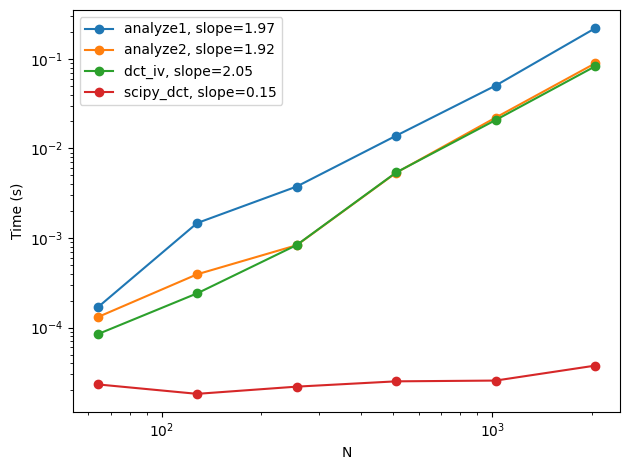

In [6]:
for name, bests in results.items():
    plot_bests(ns, bests, name)

decorate(xlabel='N', ylabel='Time (s)', xscale='log', yscale='log')
plt.legend();

Вывод: `analyze2` и матричная `dct_iv` растут примерно квадратично, а `scipy.fftpack.dct` заметно быстрее благодаря оптимизированному алгоритму.